In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3
import bisect

In [2]:
def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [51]:
file = "results/utm15_2_results_len30.pkl"
max_runtime = 100_000
utm_num_runtimes = np.zeros(max_runtime, dtype=int)
utm_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

with open(file, "rb") as f:
    while True:
        try:
            batch = pickle.load(f)
            for length, steps in batch:
                utm_num_runtimes[steps] += 1
                utm_num_runtimes_weighted[steps] += 2.0 ** (-length - 2*np.log2(length) - 2)
        except EOFError:
            break

In [47]:
file = "results/bf_results_len11.pkl"
bf_num_runtimes = np.zeros(max_runtime, dtype=int)
bf_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    weight = 8 ** (-length + 1)
    bf_num_runtimes[steps] += 1
    bf_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(bf_num_runtimes[:1000])} with {max(bf_num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 9 with 322294 programs
Processed 2000000 results, most common runtime: 9 with 733867 programs
Processed 3000000 results, most common runtime: 9 with 925725 programs
Processed 4000000 results, most common runtime: 9 with 996470 programs
Processed 5000000 results, most common runtime: 10 with 1187862 programs
Processed 6000000 results, most common runtime: 10 with 1693327 programs
Processed 7000000 results, most common runtime: 10 with 2309476 programs
Processed 8000000 results, most common runtime: 10 with 2942297 programs
Processed 9000000 results, most common runtime: 10 with 3391016 programs
Processed 10000000 results, most common runtime: 10 with 3488850 programs
Processed 11000000 results, most common runtime: 10 with 3712292 programs
Processed 12000000 results, most common runtime: 10 with 3712567 programs
Processed 13000000 results, most common runtime: 10 with 3712803 programs
Processed 14000000 results, most common runtime: 10 wit

In [48]:
file = "results/tag_results_len13.pkl"
tag_num_runtimes = np.zeros(max_runtime, dtype=int)
tag_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# Precompute cumulative counts and weights for O(1) lookup
lengths = list(range(3, 25))
partitions = [(l - 1) * (l - 2) // 2 for l in lengths]
counts = [(3 ** (l + 1)) * p for l, p in zip(lengths, partitions)]
cum_counts = list(np.cumsum(counts))

# Weighting by total rule length (4-character alphabet: 'a','b','c','H')
weights_lookup = [4 ** (-(l + 3)) for l in lengths]

counter = 0
for result in stream_results(file):
    counter += 1
    program_index, steps = result
    
    # Reconstruct length and weight
    len_idx = bisect.bisect_right(cum_counts, program_index)
    weight = weights_lookup[len_idx]
    
    tag_num_runtimes[steps] += 1
    tag_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter:,} results, most common runtime: {np.argmax(tag_num_runtimes[:1000])} with {max(tag_num_runtimes[:1000])} programs")


Processed 1,000,000 results, most common runtime: 2 with 311426 programs
Processed 2,000,000 results, most common runtime: 2 with 595906 programs
Processed 3,000,000 results, most common runtime: 2 with 861364 programs
Processed 4,000,000 results, most common runtime: 2 with 1106540 programs
Processed 5,000,000 results, most common runtime: 2 with 1358471 programs
Processed 6,000,000 results, most common runtime: 2 with 1603372 programs
Processed 7,000,000 results, most common runtime: 2 with 1847054 programs
Processed 8,000,000 results, most common runtime: 2 with 2106833 programs
Processed 9,000,000 results, most common runtime: 2 with 2364012 programs
Processed 10,000,000 results, most common runtime: 2 with 2601841 programs
Processed 11,000,000 results, most common runtime: 2 with 2815655 programs
Processed 12,000,000 results, most common runtime: 2 with 3026252 programs
Processed 13,000,000 results, most common runtime: 2 with 3237938 programs
Processed 14,000,000 results, most co

In [49]:
file = "results/rule110_results_len24.pkl"
rule110_num_runtimes = np.zeros(max_runtime, dtype=int)
rule110_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    weight = 2 ** (-length - 2*np.log2(length) - 2)
    rule110_num_runtimes[steps] += 1
    rule110_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(rule110_num_runtimes[:1000])} with {max(rule110_num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 140 with 14368 programs
Processed 2000000 results, most common runtime: 133 with 26744 programs
Processed 3000000 results, most common runtime: 133 with 37124 programs
Processed 4000000 results, most common runtime: 133 with 45431 programs
Processed 5000000 results, most common runtime: 49 with 59205 programs
Processed 6000000 results, most common runtime: 133 with 66038 programs
Processed 7000000 results, most common runtime: 133 with 75216 programs
Processed 8000000 results, most common runtime: 133 with 85400 programs
Processed 9000000 results, most common runtime: 140 with 97731 programs
Processed 10000000 results, most common runtime: 140 with 109671 programs
Processed 11000000 results, most common runtime: 140 with 121464 programs
Processed 12000000 results, most common runtime: 140 with 135085 programs
Processed 13000000 results, most common runtime: 140 with 146856 programs
Processed 14000000 results, most common runtime: 140 with

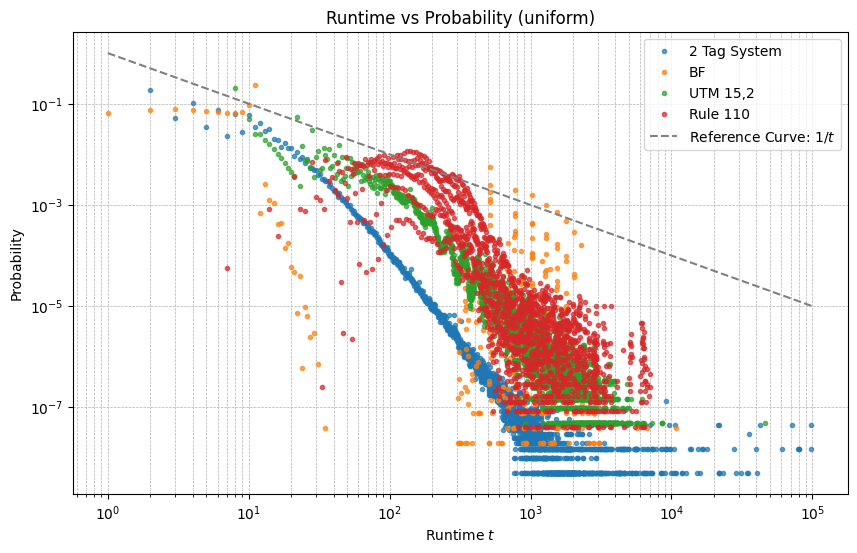

In [30]:
# log-log plot of runtimes against probability
utm_total_programs = np.sum(utm_num_runtimes)
utm_probabilities = utm_num_runtimes / utm_total_programs

bf_total_programs = np.sum(bf_num_runtimes)
bf_probabilities = bf_num_runtimes / bf_total_programs

tag_total_programs = np.sum(tag_num_runtimes)
tag_probabilities = tag_num_runtimes / tag_total_programs

rule110_total_programs = np.sum(rule110_num_runtimes)
rule110_probabilities = rule110_num_runtimes / rule110_total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), tag_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")
plt.loglog(np.arange(max_runtime), bf_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="BF")
plt.loglog(np.arange(max_runtime), utm_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")
plt.loglog(np.arange(max_runtime), rule110_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Rule 110")

reference_curve = 1 / np.arange(1, max_runtime)
plt.loglog(np.arange(1, max_runtime), reference_curve, color='grey', linestyle='--', label='Reference Curve: $1/t$')
plt.legend()

plt.title('Runtime vs Probability (uniform)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

/tmp/ipykernel_744905/2221466675.py:25: RuntimeWarning: divide by zero encountered in log2
  reference_curve = 2 ** (-np.log2(x_range) - 2*np.log2(np.log2(x_range)) - 2)


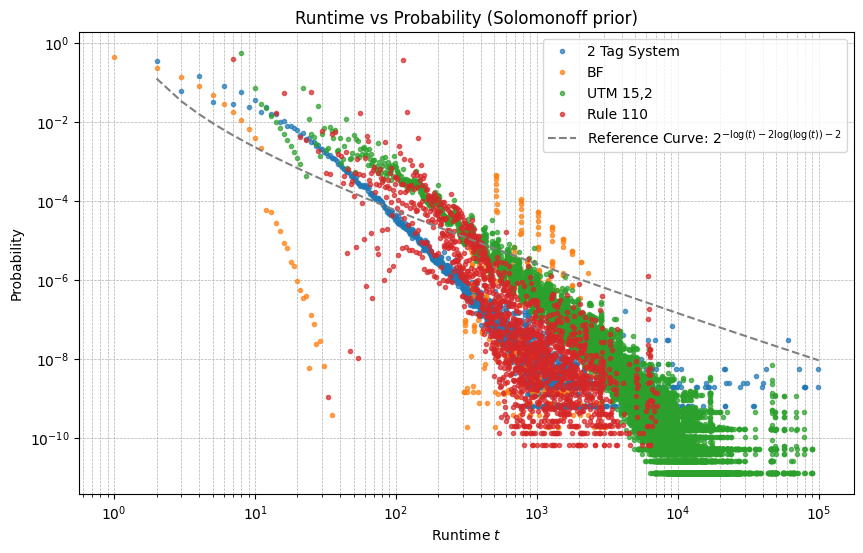

In [53]:
from IPython.core import prefilter
from IPython.core import prefilter
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

bf_total_programs_weighted = np.sum(bf_num_runtimes_weighted)
bf_probabilities_weighted = bf_num_runtimes_weighted / bf_total_programs_weighted

tag_total_programs_weighted = np.sum(tag_num_runtimes_weighted)
tag_probabilities_weighted = tag_num_runtimes_weighted / tag_total_programs_weighted

rule110_total_programs_weighted = np.sum(rule110_num_runtimes_weighted)
rule110_probabilities_weighted = rule110_num_runtimes_weighted / rule110_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), tag_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")
plt.loglog(np.arange(max_runtime), bf_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="BF")
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")
plt.loglog(np.arange(max_runtime), rule110_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Rule 110")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range) - 2*np.log2(np.log2(x_range)) - 2)
plt.loglog(np.arange(1, max_runtime), reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
1